# Illustration of extended PINN Problems

In [1]:
import os
# Surpress unnecessary output from tensorflow package
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# Change the working dorectory, for easier imports and running
os.chdir(os.path.dirname(os.path.abspath('../pyproject.toml')))

# Import necessary functions/ packages
from Utils.plot import simp_plot, plot_err_vs_epoch, mult_2D_plot
from PINNLearning.data import set_boundaries, add_noise, alph_sim, gen_data
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

We first need to set some global values and settings:

In [2]:
# Plot settings
plt.close('all')
plt.rcParams['font.size'] = 10

# Dimensions of the simulation space
lower_bound = 0.0
upper_bound = 1.0

## Inverse Problem

We are addressing the so-called **inverse problem**. Here, the objective is not only to _identify the described equation_ but also to simultaneously determine the _unknown parameters_ of the differential equation itself. To illustrate this, we will again consider the modified, one-dimensional heat equation in a normalized problem space:

$$u(x) = \dfrac{d}{dx} \left[ \alpha(x) \cdot \dfrac{d}{dx} u(x) \right]$$

As the boundary conditions, we impose the Dirichlet conditions form before:

$u(0) = 1$ and $u(1) = 0$

In this formulation, we take the diffusivity $\alpha(x)$ as _undefined_. This allows the modeling of differential equations that are known, while specific parameters remain unknown. Utilizing PINNs, it becomes feasible to learn not only the underlying function $u(x)$ but also the missing parameter $\alpha(x)$. The DeepXDE framework, discussed in the previous section of the notebook titled `2D & time dependent`, facilitates this process.

Given that some information from the problem is missing, it must be supplemented with additional data in the form of **measurement points** of the function we aim to approximate. This approach is effective whether $\alpha(x)$ is a _constant value_ or a _spatially varying function_.

To obtain this data, the simulations for varying material conditions from the last problem in the `1D & time independent` notebook are used. Additionally noise will be introduced to create a more realistic dataset. The additional data will be treated similarly to the author’s approach, entered as Dirichlet conditions.

In [3]:
# Set alpha as a constant value
def alph_const(x):
    return 0.1  # small value ensures curvature

# Set tha alpha as a inverted sigmoid funciton with k=7
def alph_func(x):
    return 1 / (1 + np.exp(7 * (x - 0.5)))

# Draw both for visual comparison
x_data = gen_data(0, 1, 100)
# Set the boundary conditions
_, y_bc = set_boundaries([[0.0], [1.0]], [[1.0], [0.0]])

# Ideal data for comparison
y_true_alph_const = alph_sim(x_data, y_bc, alph_const)
y_true_alph_func = alph_sim(x_data, y_bc, alph_func)

# Noisy measurements
y_noisy_alph_const = add_noise(y_true_alph_const, 0.2)
y_noisy_alph_func = add_noise(y_true_alph_func, 0.2)

### Simplified Case with Constant Diffusivity

In the simpler case where $\alpha(x)=const$, the equation we aim to identify can be expressed as:

$u(x)= \alpha \cdot \dfrac{d^2 u(x)}{d x^2}$

​
In this formulation, we define $\alpha(x)$ as a variable and proceed to formulate the problem in the same manner as before.


It is crucial to note that $\alpha$ appears **here** in the term with the second derivative. If the value of that derivative _approaches zero_ (the function we are attempting to approximate is linear), it hinders the updating process of $\alpha$. For the learning algorithm to effectively update this value, the underlying function _must_ exhibit **curvature**, otherwise, the model will fail to capture the necessary dynamics of the system.

This **dependency on the structure of the differential** equation is _significant_. Thus, careful consideration of the underlying function’s characteristics is essential for successful parameter identification. This is a general concern for such inverse problems.

In [4]:
# Import deepXDE AFTER using Tf 2
import deepxde as dde

# Define alpha as a trainable variable with an initial guess of 1.0
alpha = dde.Variable(1.0)

# The PDE now uses the trainable variable 'alpha'
def heat_equation_const(x, u):
    u_xx = dde.grad.hessian(u, x, i=0, j=0)
    return u - alpha * u_xx

# Definition of the geometry
x_domain = dde.geometry.Interval(lower_bound, upper_bound)

Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Instructions for updating:
non-resource variables are not supported in the long term


In [5]:
# Create a Dirichlet boundary condition from the "measured" data points
observation_data = dde.icbc.PointSetBC(
    x_data,                              # x-points in space
    y_noisy_alph_const,                  # values at the points
    component=0                          # which output from the PINN needs to satisfy this
)

# Create the Dirichlet boundary conditions on x-domain
x_bc = dde.icbc.DirichletBC(
    x_domain,
    lambda bps: 1 - bps[:],
    lambda _, on_boundary: on_boundary,
    component=0
)

Compiling model...
Building feed-forward neural network...
'build' took 0.078212 s

'compile' took 0.414212 s

INFO:tensorflow:Restoring parameters from ./data/sp_inverse_simp/inverse_simp-2000.ckpt
Compare the values for the alpha constant:
     Inferred Alpha                    Simulated Alpha
       0.09752623                            0.1


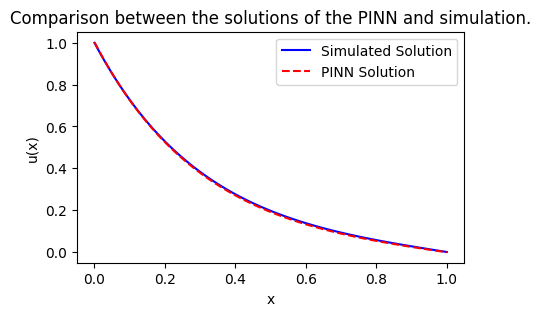

In [6]:
# Create the data object now including the observation data
data = dde.data.PDE(
    x_domain,
    heat_equation_const,
    [x_bc, observation_data],
    num_domain=2540,
    num_boundary=80,
    num_test=2540
)

# Create the neural network
net = dde.nn.FNN([1] + [50] * 3 + [1],
                "tanh",
                "Glorot uniform",
                regularization=["l2", 1e-4]
)
model = dde.Model(data, net)
model.loss_weights = [200, 100, 50, 1]  # [inner, bc, points, reg]
# FYI: Alpha is part of the pde (inner) loss term as such the attention
# for training must lie here. The large weight scalar values force the
# trainer to go through more steps for convergence.

# Inform the compiler about the trainable variable
model.compile(
    "adam",
    lr=1e-3,
    external_trainable_variables=[alpha]
)

# Check the progress of alpha
var_callback = dde.callbacks.VariableValue(
    [alpha],
    period=200
)

# Train the model if it is not already trained
if os.path.exists('./data/sp_inverse_simp/inverse_simp-2000.ckpt' + ".index"):
    # To force retraining of the model just change the string

    model.restore('./data/sp_inverse_simp/inverse_simp-2000.ckpt')
else:
    losshistory, train_state = model.train(
        iterations=2000,
        display_every=200,
        callbacks=[var_callback]
    )
    model.save("./data/sp_inverse_simp/inverse_simp")

    # Create a graph showing the loss vs the epochs
    x = np.array(losshistory.steps)
    y = np.array([np.sum(loss) for loss in losshistory.loss_train])
    data = list([x, y, 'g-', 'Model Loss'])
    plt = plot_err_vs_epoch(data, 'Development of the Loss over the Epochs', xlabel='Epochs', ylabel='Loss')
    plt.show()

# Comapare the Value of alpha
print("Compare the values for the alpha constant:")
print(5*" " + "Inferred Alpha" + 20*" " + "Simulated Alpha")
print(7*" " +  f"{model.sess.run(alpha):.8f}" + 28*" " + f"{alph_const(0)}")

# Visualy compare the PINN with the simulation
x_points = x_domain.uniform_points(100)
y_pred = model.predict(x_points)

data = [
    [x_data.numpy(), y_true_alph_const, 'b-', ('label', 'Simulated Solution')],
    [x_points, y_pred, 'r--', ('label', 'PINN Solution')]
]
plt = simp_plot(data, 'Comparison between the solutions of the PINN and simulation.', ylabel='u(x)')
plt.show()

The model demonstrates a satisfactory fit to the noisy data and effectively predicts $u(x)$.
The parameter $\alpha$ was accurately estimated, although it is important to acknowledge that this value is subject to error. When rounded to an appropriate number of decimal places, the apparent error may seem negligible. However, in the context of an entirely unknown problem, determining the "correct" number of decimal places remains ambiguous, presenting a significant consideration in the analysis.

### Complex Case with Spatially Varying Diffusivity

In the more complex scenario where $\alpha(x)$ is defined as a _function_ rather than a constant, it cannot simply be treated as a variable. Instead, $\alpha(x)$ must be represented as a **neural network** itself. This approach allows for the modeling of spatially varying diffusivity, which can capture more intricate behaviors of the system.
The model object of DeepXDE is designed to work with a single model, enabling the integration of the diffusivity into the _same_ neural network that approximates $u(x)$. While a Parallel Fully-Connected Neural Network (PFNN) can be implemented, mapping collected inputs through individual sub-networks to each output, this approach requires specific conditions for each output and reduces the correlation between them, which is obviously undesirable in this case.
However, integrating the diffusivity into a single neural network is very _challenging_ as well, as it necessitates the network to learn both the underlying function and the spatially varying parameter simultaneously. This can lead to conflicting gradients or operate on different scales, complicating the learning process.


In many cases, there are **NO** explicit boundary or initial conditions for the function $\alpha(x)$. This flexibility means that $\alpha(x)$ can be represented as **ANY** function that is describable by the chosen neural network architecture. While it is generally _not strictly necessary_ to provide these conditions, as the problem is sufficiently defined by the conditions and additional data for $u(x)$, incorporating prior knowledge about $\alpha(x)$ can significantly enhance the model’s performance and even be a requirement for convergence. This prior knowledge can include a **smoothness regularization term** that penalizes the gradient of $\alpha(x)$, **constraints** such as positivity or boundedness, or even an **informative initial guess**.


For the problem at hand, as we are examining the diffusivity of a material, we can be confident that this function will always be _positive_. Additionally, since we are operating in a normalized space, the function will never exceed a _value of one_. These limits can be enforced by applying a **clipping function** as an output transformation (hard constraint) to the utilized FNN architecture. However, this clipping function introduces certain obvious challenges that must be addressed through pre-training (warm starting) the model.
Furthermore, based on the sampled data, we can infer that the function should exhibit larger values for $x$ close to $0$ and lower values as $x$ approaches $1$, with smooth transitions. Therefore, we can propose an _initial guess_ for this function in the following form:

$ \alpha_{prior}(x) = \frac{1}{2} \cdot (\cos(\pi \cdot x) + 1)$


Such an initial guess is imposed as an additional loss term for the trainer to optimize. To further assist the model in converging to the proper solutions, three modifications were made to the setup from the previous example:

- The boundary conditions of $u(x)$ are included as **hard conditions** (as output transformations instead of loss terms). This approach forces the output of the model to yield the correct values, providing a much stronger condition that facilitates quicker convergence.

- The differential equation is reformulated as a **system of two first-order equations**:
    $\begin{align}
        u(x) &= \dfrac{d}{dx} v(x) \\
        v(x) &= a(x) \cdot \dfrac{d}{dx} u(x)
    \end{align}$
    This change eliminates the second-order automated derivatives from the framework, reducing the error in the system since that derivative is more error-prone than the first-order derivatives.

- A **curriculum learning** regime was adopted. This concept describes the learning process in a progressive manner, where a problem is modified in multiple steps (phases) from an initial to a final (originally intended) problem. This approach allows the model to first learn a specific (typically simplified) representation of the problem and then refine that solution towards the actual one as the learning phases progress. In this case, curriculum learning was employed to address the challenges introduced by the clipping function for the output of $\alpha(x)$, warm starting the whole training process. The following initial learning focused on $u(x)$ based on its sample data, and subsequently, the solution of $u(x)$ was refined to accurately determine the correct $\alpha(x)$.


In [5]:
# Define the PDE with the input u containing both
# the two 1D equations and alpha
def heat_equation_func(x, u):
    u_val, v_val, alpha = u[:, 0:1], u[:, 1:2], u[:, 2:3]

    # derivatives of the individual parts
    u_x = dde.grad.jacobian(u, x, i=0, j=0)
    v_x = dde.grad.jacobian(u, x, i=1, j=0)
    # assamble the two equations
    eq1 = v_x - u_val
    eq2 = v_val - alpha * u_x
    return [eq1, eq2]

# Update the Dirichlet condition of the "measured" data points
observation_data = dde.icbc.PointSetBC(
    x_data,
    y_true_alph_func,
    component=0  # here setting this correctly is immperative!
                 # --> should only be ative for u(x)
)

In [6]:
# Introduce a variable to controle the initial two training phases
phase = tf.Variable(1, trainable=False)
# FYI: Must be a tf.Variable as only this way it gets included in the 
# network graph (thus it will be automatically saved and restored by
# DeepXDE), without being trainable.

# Create the transformation for the output of the FNN
def transform_output(x, y):
    # split the output of the model
    u_raw, v, alpha_raw = y[:, 0:1], y[:, 1:2], y[:, 2:3]
    # enforce the boundaries as hard boundary conditions
    u = (1 - x) + x * (1 - x) * u_raw
    # switch between the initializer that forces alpha to be in (0,1)
    # and the hard constraint depending on the training phase
    alpha = tf.cond(tf.equal(phase, 1),
                    lambda: tf.sigmoid(alpha_raw - 0.5),
                    lambda: tf.clip_by_value(alpha_raw, 0, 1)
    )
    # combine all outputs to match the normal model output
    return tf.concat([u, v, alpha], axis=1)

# Calculate the residual of the soft constraint based on the intial
# guess for alpha
def alpha_res(x, u, X):
    cos = 0.5 * (tf.math.cos(tf.constant(np.pi) * x) + 1) + 1e-6
    # add 1e-6 for numerical stability
    return u[:, 2:3] - cos

# Introduce the initial guess as condition for the optimizer
alpha_prior = dde.icbc.OperatorBC(
    x_domain,
    alpha_res, # The operator function 
    lambda _, on_boundary: not on_boundary  # active only on the inside
)
# FYI: Unlike in the other definitions, here the value of the boundary
# is encoded into the operator function. This function takes a set of 
# input points, the corresponding output of the network and a numpy list
# of the coordinates of the input points. It returns the RESIDUAL
# instead of the actual value of the boundary condition!

In [7]:
# Create the data objects now including the observation data
# and the prior
data = dde.data.PDE(
    x_domain,
    heat_equation_func,
    [observation_data, alpha_prior],
    num_domain=3500,
    num_boundary=80,
    num_test=3500
)

# Define the nerual network
net = dde.nn.FNN([1] + [50] * 5 + [3],  # output = u(x), v(x), alpha(x)
               "tanh",
               "Glorot uniform",
               regularization=["l2", 1e-4]
)
# Apply the output transformation
net.apply_output_transform(transform_output)
model2 = dde.Model(data, net)
model2.compile("adam", lr=1e-3, loss_weights=[10, 100, 500, 1, 1])  # [eq1, eq2, points, prior, reg]
# FYI: As alpha is included in the equations and there are an 
# theoretically infinit amount of solutions for alpha, we must force
# the training to converge to OUR specific solution. Thus the emphasis
# for training must be placed on the points term.

# Train the model if it is not already trained
if os.path.exists('./data/sp_inverse_func/inverse_func-5000.ckpt' + ".index"):
    # To force retraining of the model just change the string

    model2.compile("adam", lr=1e-3, loss_weights=[10, 100, 500, 10, 1])
    model2.restore('./data/sp_inverse_func/inverse_func-5000.ckpt')
else:
    # In the first phase set up training and start initialization of the network
    losshistory, train_state = model2.train(500)
    # FYI: Important as the hard constraints on alpha are reinforced using a clip function.
    # If not done, the network might randomly be initialized with alpha below 0 and
    # thus destroying all gradients. NO update to the weights would happen.

    # Switch to the second training phase, for this "turn off" the initializer transform on 
    # alpha by using the variable "inside" of the model
    model2.sess.run(phase.assign(2))
    # Train second phase with activated hard constraints and lower weight for the alpha_prior
    model2.train(1500, display_every=200)
    # FYI: Initially prioritize the learning of the u(x) instead of the a(x).

    # Train third phase with larger weight for alpha_prior
    model2.compile("adam", lr=1e-3, loss_weights=[10, 100, 500, 10, 1])
    model2.train(3000, display_every=200)
    # FYI: After u(x) is good enough, try to find a(x) that fits and improves u(x)
    # correspondingly.

    model2.save("./data/sp_inverse_func/inverse_func")

    # Create a graph showing the loss vs the epochs
    x = np.array(losshistory.steps)
    y = np.array([np.sum(loss) for loss in losshistory.loss_train])
    data = list([x, y, 'g-', 'Model Loss'])
    plt = plot_err_vs_epoch(data, 'Development of the Loss over the Epochs', xlabel='Epochs', ylabel='Loss')
    plt.show()

Compiling model...
Building feed-forward neural network...
'build' took 0.155129 s

'compile' took 0.776057 s

Compiling model...
'compile' took 0.464452 s

INFO:tensorflow:Restoring parameters from ./data/sp_inverse_func/inverse_func-5000.ckpt


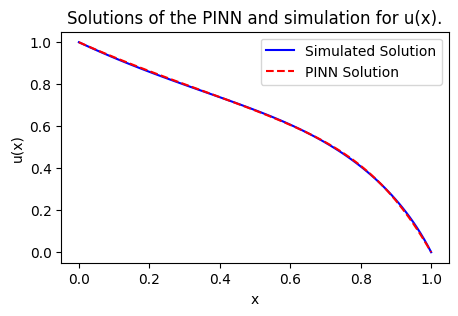

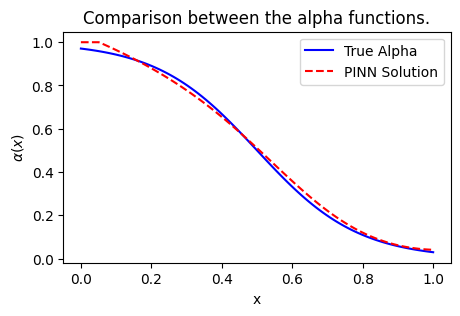

In [8]:
# Visualy compare the PINN with the simulation and the true alpha
x_points = x_domain.uniform_points(100)
y_pred = model2.predict(x_points)
alpha_points = alph_func(x_points)

# Compare the u(x)
data = [
    [x_data.numpy(), y_true_alph_func, 'b-', ('label', 'Simulated Solution')],
    [x_points, y_pred[:, 0:1], 'r--', ('label', 'PINN Solution')]
]
plt = simp_plot(data, 'Solutions of the PINN and simulation for u(x).', ylabel='u(x)')
plt.show()

# Compare the a(x)
data = [
    [x_data.numpy(), alpha_points, 'b-', ('label', 'True Alpha')],
    [x_points, y_pred[:, 2:3], 'r--', ('label', 'PINN Solution')]
]
plt = simp_plot(data, 'Comparison between the alpha functions.', ylabel=r'$\alpha(x)$')
plt.show()

When addressing this problem, it becomes evident that the correct solution for $u(x)$ is readily obtained. The results demonstrate a strong alignment with the expected solution.
In contrast, the estimation of $\alpha(x)$ presents a more complex challenge. Achieving convergence of the model towards the true solution is notably difficult, and the results indicate that the solution still exhibits some errors. This discrepancy likely arises from the initial guess for $\alpha(x)$, which may not fully represent the actual function. While increasing the number of training epochs could potentially improve the model’s performance, it remains uncertain whether this approach will definitively resolve the issue.

Consequently, it is crucial to account for the (potentially significant) errors in the prediction of the unknown value and to carefully consider the challenges associated with training in this context.

## Learning various Boundary Conditions

In this series of notebooks, we have demonstrated the feasibility of learning the solution to a differential equation given specific boundary and initial conditions. This raises an important question: **is it possible to not only learn a single solution to the equation but also to learn all possible solutions?**

Such problems are typically classified as **parameterized problems**. They are generally addressed using _one or a combination_ of the following two methodologies:
- Parameterized Physics-Informed Neural Networks (P-PINNs)
- Meta-Learning or Transfer Learning


While other methods exist, these two are the most frequently discussed in the literature. The first approach, incorporates additional parameters (such as boundary conditions and potentially other factors like the diffusivity in this case) as input variables into the neural network. By significantly expanding the dimensions of the neural network, it becomes possible to learn the mapping from these parameters to the corresponding solutions.
The second approach emphasizes rapid adaptation of a pre-trained model to new conditions. For a more comprehensive understanding of these topics, refer to the paper by [Cho W. et al., 2024](https://arxiv.org/abs/2408.09446v1).

For this problem, we return to the following initial problem in the notebook `1D & time independent` and discuss the parameterized approach:

$$u(x) = \alpha \cdot \dfrac{d^2}{dx^2} u(x)$$

The problem is again normalized over the range $[0,1]$, with $\alpha = 1$ and the Dirichlet boundary conditions specified as:

$u(0) = u_0$ and $u(1) = u_1$

In this context, the set of possible values for both conditions encompasses _all numbers_ within the range $[0,1]$ and _any conceivable combination_ of these values. The framework is established similarly to previous implementations, with the key difference being that the boundary conditions are _included as inputs_ to the network. Additionally, the depth of the network is significantly increased. Although this increase exceeds what is strictly necessary, it substantially _enhances_ the predictive performance of the model.

In [6]:
# Define the simplified heat equation from before
def simp_heat_equation(x, u):
    u_xx = dde.grad.hessian(u, x, i=0, j=0)
    return u - u_xx

# Use a hypercube to represent the combined input space of (x, u_0, u_1).
domain = dde.geometry.Hypercube(xmin=[lower_bound]*3, xmax=[upper_bound]*3)

# Calculate the residual for the left BC: u(0) - u_0 = 0.
def bc_op_left(x, u, X):
    return u - x[:, 1:2]

# Create the OperatorBC for the left boundary
bc_left = dde.icbc.OperatorBC(
    domain,
    bc_op_left,
    lambda bp, on_boundary:
        on_boundary and np.isclose(bp[0], lower_bound)
)

# Calculate the residual for the right BC: u(1) - u_1 = 0.
def bc_op_right(x, u, X):
    return u - x[:, 2:3]

# Create the OperatorBC for the right boundary
bc_right = dde.icbc.OperatorBC(
    domain,
    bc_op_right,
    lambda bp, on_boundary:
        on_boundary and np.isclose(bp[0], upper_bound)
)

In [7]:
# Comnine everythin into the data object
data = dde.data.PDE(
    domain,
    simp_heat_equation,
    [bc_left, bc_right],
    num_domain=3500,
    num_boundary=1000,
    num_test=3500
)

# The network takes 3 inputs (x, u0, u1)
net = dde.nn.FNN([3] + [50] * 10 + [1],
                "tanh",
                "Glorot uniform",
                regularization=["l2", 1e-4]
)
model3 = dde.Model(data, net)
model3.compile("adam", lr=1e-3)

# Train the model if it is not already trained
if os.path.exists('./data/sp_multi_bc/multi_bc-4000.ckpt' + ".index"):
    # To force retraining of the model just change the string

    model3.restore('./data/sp_multi_bc/multi_bc-4000.ckpt')
else:
    losshistory, train_state = model3.train(
        iterations=4000,
        display_every=500
    )
    model3.save("./data/sp_multi_bc/multi_bc")

    # Create a graph showing the loss vs the epochs
    x = np.array(losshistory.steps)
    y = np.array([np.sum(loss) for loss in losshistory.loss_train])
    data = list([x, y, 'g-', 'Model Loss'])
    plt = plot_err_vs_epoch(data, 'Development of the Loss over the Epochs', xlabel='Epochs', ylabel='Loss')
    plt.show()

Compiling model...
Building feed-forward neural network...
'build' took 0.168525 s

'compile' took 0.952552 s

INFO:tensorflow:Restoring parameters from ./data/sp_multi_bc/multi_bc-4000.ckpt


As illustrated below, we compare the predictions for the randomly sampled boundary conditions with the analytical solution given by:

$u(x, u_0, u_1) = \dfrac{u_0 \cdot (e^{1-x}-e^{x - 1}) + u_1 \cdot (e^{x}-e^{-x})}{e^{1}-e^{-1}}$

This analytical solution was derived in the same manner as in the initial instance of this problem, utilizing the general Dirichlet boundary conditions specified earlier.


The results indicate that, in the majority of cases, the predictions generated by the PINN align closely with the corresponding analytical solutions. This demonstrates that a PINN **can be effectively extended to capture the entirety of the problem** rather than merely a subset of it. Given that inference on an AI model is _significantly more efficient_ than traditional simulation or retraining methods, it can be advantageous to allocate additional resources towards training this larger model.
However, it is important to note that this approach is mainly applicable to _relatively_ simple equations. While it theoretically extends to more complex equations, the size of the neural network increases substantially, complicating the problem.

In the context of varying initial conditions, research conducted in the master’s thesis by [Schäfer V., 2022](https://elib.dlr.de/185457/1/master_thesis.pdf) has shown that these conditions demonstrate difficulties when modeled in the same manner. Instead, they necessitate the application of more advanced meta-learning techniques.

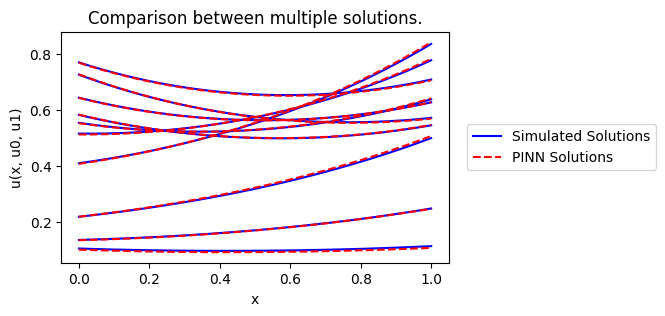

In [8]:
# Visualy compare the PINN with the simulation

# Define the analytical solution depending on the provided
# boundary conditions of the diff. eq.
def analytical_solution(x, u0, u1):
    denom = np.exp(1) - np.exp(-1)
    num_left = u0 * (np.exp(1-x) - np.exp(x-1))
    num_right = u1 * (np.exp(x) - np.exp(-x))
    return (num_left + num_right)/denom

# Create the array of point coordinates
x_points = np.linspace(lower_bound, upper_bound, 1000)
u0_points = np.random.uniform(lower_bound, upper_bound, (10, 1))
u1_points = np.random.uniform(lower_bound, upper_bound, (10, 1))

# Initialize empty lists to store the resulting arrays
y_sim = []
y_pred = []
# Loop through each of the 10 pairs of u0 and u1 values
for i in range(len(u0_points)):
    # Select the i-th value from u0_points and u1_points
    u0_current = u0_points[i]
    u1_current = u1_points[i]

    # Repeat the current u0 and u1 values to match the length of x_points
    u0_repeated = np.repeat(u0_current, len(x_points))
    u1_repeated = np.repeat(u1_current, len(x_points))
    # Create a single array with 1000 rows and 3 columns
    combined_vector = np.column_stack((x_points, u0_repeated, u1_repeated))
    # Add the resulting arrays to the lists
    y_sim.append(analytical_solution(x_points, u0_current, u1_current))
    y_pred.append(model3.predict(combined_vector))

data = [
    [x_points, y_sim, 'b-', ('label', 'Simulated Solutions')],
    [x_points, y_pred, 'r--', ('label', 'PINN Solutions')]
]
plt = mult_2D_plot(data, 'Comparison between multiple solutions.', ylabel='u(x, u0, u1)')
plt.show()

## Neural Operators

[Neural Operators](https://en.wikipedia.org/wiki/Neural_operators) are a class of machine learning models designed to learn **mappings between function spaces**, enabling them to approximate complex [operators](https://en.wikipedia.org/wiki/Operator_(mathematics)) efficiently. These operators are employed as the mapping from an input function, defined by the initial or boundary conditions ([Enyart D. and Lin G., 2024](https://arxiv.org/abs/2412.06686v1)), coefficient fields ([Kovachki N. et al., 2024](https://arxiv.org/abs/2108.08481)), or source terms of a given differential equation, to the corresponding output function that represents the solution.
In general such problems can also be interpreted as image-to-image learning tasks.


This approach of learning the mapping provides _significant_ **advantages** in various applications due to the resulting **ability to generalize across diverse input functions without the need for retraining**. This flexibility allows for effective adaptation to _various conditions_, as described in the previous section, while also **reducing computational costs** once trained.
By learning from entire function spaces rather than just discrete data points, Neural Operators excel at capturing the _complex relationships_ inherent in physical systems, facilitating **predictions with high accuracy**. Additionally, their capability to handle different resolutions of functions enables them to provide **accurate solutions across a range of scales**, making them particularly beneficial for multi-scale problems ([Joshi P., 2024](https://prateekjoshi.substack.com/p/building-science-ai-models-with-neural)).


While both Neural Operators and PINNs aim to solve differential equations, they differ _fundamentally_ in their approach.
Neural Operators focus on learning the operator _itself_ and are designed to handle a wide range of input scenarios, allowing them to generalize well across different problems without needing to retrain for each specific case. However, they are typically trained using a supervised learning regime and tend to be more expensive at that, also requiring a larger set of training data.
In contrast, PINNs _incorporate_ the physical laws governing the system directly into the neural network’s loss function. They typically learn from data vectors (which are referred to as tensors in TensorFlow), representing _specific instances or samples of the problem_. This approach limits their ability to generalize across different scenarios but allows them to be comparatively _easier_ to train, _reduces_ the amount of necessary data, and _improves_ results for especially complex problems (such as intricate geometries of the problem space) by narrowing down the possible solutions.
In summary, Neural Operators provide a more generalized framework for function approximation, while PINNs are tailored for specific physical systems governed by known equations.

***

According to the study by [Liu S. et al., 2025](https://www.sciencedirect.com/science/article/pii/S0925231225011907) (to which you can also refer to for further information and a comparison between all of these methods), current research on neural operators can be divided into _three_ general architectures, each serving as a foundation for various extensions and modifications. The architectures are:
- **Deep Operator Networks (DeepONets)**
- **Integral Kernel Neural Operators** (e.g., Fourier Neural Operators (FNOs))
- **Transformer-based Neural Operators**

**DeepONet**<br>
The first architecture, conceived by [Lu L. et al., 2019](https://arxiv.org/abs/1910.03193), consists of _two_ main components: the **branch network** and the **trunk network**, as illustrated in the image from that work below.

The **branch network** takes a _function as input_, typically represented as a set of discrete points evaluated at sampled positions across the domain. It is common to also include the coordinates of the sampled points as input to the model. This set of values is entered _simultaneously_ into a [Convolutional Neural Network (CNN)](https://medium.com/thedeephub/convolutional-neural-networks-a-comprehensive-guide-5cc0b5eae175) with the goal of learning the correct [latent representation](https://medium.com/biased-algorithms/a-comprehensive-guide-to-latent-space-in-machine-learning-b70ad51f1ff6) of the function in a $p$-dimensional manifold.


In contrast, the **trunk network** takes a _single point_ in the output space (e.g., a spatial or temporal location) as input and learns to map this point into the _same_ latent space as the branch network. The corresponding scalar output value of the operator is generated by applying the inner (dot) product on the two latent feature vectors.

<img src="../data/images/DeepONet non-stacked architecture.png" alt="DeepONet Architecture" style="width:500px;"/>


During training, a supervised learning scheme is employed, utilizing pairs of input functions and their corresponding outputs. The training process minimizes a loss function that measures the difference between the predicted output and the true output.
The advantages of DeepONet include its efficiency in learning complex mappings between infinite-dimensional Banach spaces, flexibility in handling a wide range of input functions, and scalability to high-dimensional problems.
However, DeepONets are highly sensitive to hyperparameters, such as the architecture of the branch and trunk networks and the density of the sampled data points, which can significantly affect their learning effectiveness. Additionally, they may struggle with highly nonlinear or chaotic functions, requiring careful tuning and potentially additional techniques to capture such complexities. They may also fail to learn the underlying physical principles of the equations. To address this, **Physics-informed DeepONets** (adding the loss function of the PINNs to the trainig algorithm) have been developed. Training these networks can be computationally expensive and time-consuming, particularly due to their large training data requirements ([Viswanath H. et al., 2023](https://arxiv.org/abs/2301.13331)).

**Integral Kernal Neural Operators**<br>
These, sometimes confusingly referred to simply as _neural operators_, are a generalization of the conventional CNN architecture to continuous domains. In this framework, the discrete convolutions used in CNNs are replaced by _continuous integral operations_. Here the base idea is, that certain specified differential equations can be solved by a convolution with a _fundamental solution_ of that equation. The general structure is illustrated in the image ([Schneider M. and Innerberger M., 2024](https://janelia-cvml.github.io/blog/posts/NeuralOperators/index.html)) below.

A Neural Operator network is provided with a discretized input function $a(y)$, again represented as a set of coordinate-value pairs. The architecture processes this input through three main stages:
- The initial "Lifting" step employs a **local "P" transformation**, to map the input data into a higher-dimensional latent space (typically increasing the dimensionality). This is typically achieved with a shallow FNN that processes each input pair independently, producing the latent representation $v(y)$.
- Next, a series of **$\bf{L}$ Kernel Integration Layers ("convolutional" layers)** iteratively update this latent representation. These layers are responsible for learning the global dynamics of the system.
- The final **"Projection"** step uses another **local "Q" transformation**, to map the final latent representation to the desired output space. A key feature of this stage is that the output function, $u(x)$, can be evaluated at _any arbitrary set of query points_. This allows the operator to produce a solution at any resolution, effectively yielding a _continuous_ function representation from the discretized input.

Within each kernel integration layer, the latent function from the previous step, is updated to through two parallel operations.
First, a local linear transformation is applied via a **learnable weight matrix** $W$.
Concurrently, a global aggregation is performed using a **kernel integral transformation**. This integral computes the convolution of a _learned_ kernel, $k(x,y)$, with the respective latent input function across the entire ORIGINAL problem domain. The **kernel is parameterized by its own FNN**, which is learned independently for each layer. It models the influence of the _latent input function_ at any point y on the _latent output function_ at any other point x. The results of the local and global operations are then aggregated and passed through a non-linear activation function $\sigma$.

Since the direct computation of the integral is _often impossible_, it is approximated numerically using the discretized points. This entire update process is performed for all discretized points $y$ to generate the complete latent representation for the next layer. This architectural design ensures that the learned operator is independent of the input and output discretization, a property known as **discretization invariance**.

This summary is based on the foundational work on Fourier Neural Operators by [Li Z. et al., 2020](https://arxiv.org/abs/2010.08895), which provides further in-depth information.

<img src="../data/images/NO base architecture.png" alt="NO Architecture" style="width:850px;"/>


The computational cost of performing convolutions is _proportional to the multiplication of the input and output dimensions_, which can create a _limit_ processing efficiency. To mitigate this issue and, in some cases, enhance learning, it is beneficial to incorporate additional physical knowledge into the model. This is achieved by modifying the integral.
For instance, in the case of **Graph Neural Operators (GNOs)**, the summation is restricted to only those points that are in close proximity to one another, thereby reducing the computational burden. 
In contrast, **Fourier Neural Operators (FNOs)** replace the entire convolution operation (integral) with a multiplication in the frequency domain. This transformation is accomplished using the _Fast Fourier Transform (FFT)_ to convert both the kernel and the latent input function into the frequency space, where the product is computed, followed by an inverse transform to obtain the result in the original domain.


These **Integral Kernel Operators** excel in addressing problems characterized by complex underlying physics that necessitate a robust mathematical framework. As previously discussed, they are **resolution-invariant** and capable of **zero-shot super-resolution**. Furthermore, they exhibit flexibility and can be adapted to various problems by altering the integral formulation. However, this adaptability also renders these models **complex** to understand and interpret. Typically, they are not utilized in their general form but rather in adaptations such as _FNOs_. This specificity makes them more suitable for particular problems compared to the more general DeepONets, thereby limiting their broader applicability.
For a more comprehensive comparison between these methods and DeepONets, refer to: [Goswami S. et al., 2022](https://arxiv.org/abs/2207.05748) and [Viswanath H. et al., 2023](https://arxiv.org/abs/2301.13331).

**Transformer-based Neural Operators**<br>
Transformer-based Neural Operators were first introduced in a paper by [Cao S., 2021](https://arxiv.org/abs/2105.14995) and adapt the [transformer architecture](https://muhid-qaiser.medium.com/decoding-the-transformer-architecture-a-complete-guide-to-the-backbone-of-modern-ai-e554db9fe0c9) to the task of learning mappings between function spaces. They are built on the same foundational idea as _Integral Kernel Operators_, but with a critical substitution: the explicit **integral kernel is replaced by the self-attention mechanism**. By its nature, self-attention provides a powerful method for computing weighted, global interactions between all elements in a sequence. In this context, this sequence corresponds to a _flattened representation_ of the input values used in the prior architectures. Since self-attention alone does **not** inherently account for the _spatial arrangement_ of these points, incorporating a **position-aware modification** is necessary to preserve the underlying spatial structure of the data.

These operators follow the familiar three-stage pipeline (Lifting, Iteration, Projection), with the fundamental change located in the iterative core. Instead of a Kernel Integration Layer, a **Transformer Encoder Layer** is used to update the latent function representation. A Transformer layer is composed of two primary sub-layers:
- **Position-Aware Self-Attention**:
  This sub-layer performs the _global_ aggregation of information. For the attention mechanism to be effective for physical systems, it must be made aware of the _spatial coordinates of the input function values_. This is achieved by modifying the attention score calculation. For any two points in the domain, the score includes a **learnable positional bias term**, often modeled by a small FNN. The attention mechanism then computes a **weighted sum over all points**, where the weights are derived from these position-aware scores. This process allows the model to learn a flexible, data-driven kernel that captures the _influence of every point on every other point_.
- **Feed-Forward Network (FFN)**: 
  Following the attention step, the output is processed by a **position-wise FFN**. This network applies the same non-linear transformation to each element of the sequence independently, serving as the _local_ processing component of the update.


Regarding its properties, the self-attention mechanism is **extremely expressive** and has been shown to be a universal approximator for _sequence-to-sequence functions_. It can capture _highly_ complex and long-range dependencies without being constrained to a specific basis (like the Fourier basis in FNO).
However, the primary drawback is **computational complexity**. Standard self-attention scales _quadratically_ with the number of discretized points. This can be prohibitive for high-resolution problems and motivates ongoing research into more efficient, linear-time attention mechanisms.

Two excellent papers that provide more in-depth information on the practical implementation of these transformer-based methods and their concrete architectures for general physical problems are [Hao Z. et al., 2023](https://arxiv.org/abs/2302.14376) and [Alkin B. et al., 2024](https://arxiv.org/abs/2402.12365).

_In conclusion, it is evident that each of these methods has specific areas of strength, contingent upon the structure of the input functions, the geometry of the domain and the problem itself. Therefore, selecting the appropriate model for a given differential equation is crucial for achieving optimal results._

Actually, using these methods can prove challenging. 
Various variants of DeepONets are implemented within the DeepXDE library and can be used more or less like a drop-in replacement for the PINNs throught this series.
For Integral Kernel-based methods, specific versions are implemented in the [NeuralOperator](https://neuraloperator.github.io/dev/modules/api.html) package, which, however, uses PyTorch as the backend. This package also provides modular building blocks that allow constructing other variants manually. 
Transformer-based neural operators currently do not have a mature, dedicated Python package. However, the GNOT paper (link provided above) by Hao Z. includes a [GitHub repository](https://github.com/HaoZhongkai/GNOT) that provides code for direct execution or customization.